# Feature Engineering

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, make_scorer

In [10]:
PROCESSED_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data\processed"

preprocessor = joblib.load(os.path.join(PROCESSED_DIR, "preprocessor.joblib"))
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

In [12]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (239, 12)
X_test: (60, 12)


In [19]:
LOG_COLS = ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time"]
SCALE_COLS = ["age", "ejection_fraction", "serum_sodium"]
BIN_COLS = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

def to_raw(X_df):
    X = X_df.copy()
    col_map = {f"log__{c}": c for c in LOG_COLS}
    col_map |= {f"scale__{c}": c for c in SCALE_COLS}
    col_map |= {f"pass__{c}": c for c in BIN_COLS}
    X = X.rename(columns=col_map)

    for c in LOG_COLS:
        X[c] = np.expm1(X[c])

    scaler = preprocessor.named_transformers_["scale"]
    for c, mu, sd in zip(SCALE_COLS, scaler.mean_, scaler.scale_):
        X[c] = X[c] * sd + mu
    return X

raw_train, raw_test = to_raw(X_train), to_raw(X_test)
print(raw_train[["age", "serum_creatinine", "sex"]].head())

    age  serum_creatinine  sex
0  58.0               1.0  0.0
1  53.0               0.8  1.0
2  75.0               1.9  1.0
3  64.0               2.4  1.0
4  45.0               1.6  1.0


In [20]:
raw_train

,creatinine_phosphokinase,serum_creatinine,platelets,time,age,ejection_fraction,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
0,400.0,1.0,164000.0,91.0,58.0,40.0,139.0,1.0,0.0,0.0,0.0,0.0
1,63.0,0.8,368000.0,22.0,53.0,60.0,135.0,0.0,1.0,0.0,1.0,0.0
2,582.0,1.9,265000.0,4.0,75.0,20.0,130.0,0.0,0.0,1.0,1.0,0.0
3,143.0,2.4,246000.0,214.0,64.0,25.0,135.0,0.0,0.0,0.0,1.0,0.0
4,582.0,1.6,126000.0,180.0,45.0,20.0,135.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
234,211.0,1.2,274000.0,207.0,72.0,25.0,134.0,0.0,0.0,0.0,0.0,0.0
235,1082.0,6.1,250000.0,107.0,60.0,45.0,131.0,1.0,1.0,0.0,1.0,0.0
236,69.0,1.0,132000.0,147.0,49.0,50.0,140.0,1.0,0.0,0.0,0.0,0.0
237,369.0,1.6,252000.0,90.0,50.0,25.0,136.0,0.0,1.0,0.0,1.0,0.0


In [25]:
def add_egfr(df_new):
    df_new = df_new.copy()
    scr, age, sex = df_new["serum_creatinine"], df_new["age"], df_new["sex"]
    k = np.where(sex == 0, 0.7, 0.9)
    alpha = np.where(sex == 0, -0.241, -0.302)
    df_new["egfr"] = (142 * np.minimum(scr / k, 1.0) ** alpha * np.maximum(scr / k, 1.0) ** -1.200 * 0.9938 ** age)
    return df_new

def add_ef_group(df_new):
    df_new = df_new.copy()
    df_new["ef_group"] = np.where(df_new["ejection_fraction"] < 40, 0, np.where(df_new["ejection_fraction"] <= 49, 1, 2))
    return df_new

In [26]:
raw_tr_fe = add_ef_group(add_egfr(raw_train))
raw_te_fe = add_ef_group(add_egfr(raw_test))
print("eGFR range :", raw_tr_fe["egfr"].min().round(1), "-", raw_tr_fe["egfr"].max().round(1))
print(raw_tr_fe["ef_group"].value_counts().sort_index())

eGFR range : 4.7 - 118.0
ef_group
0    144
1     47
2     48
Name: count, dtype: int64


In [28]:
raw_tr_fe

,creatinine_phosphokinase,serum_creatinine,platelets,time,age,ejection_fraction,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking,egfr,ef_group
0,400.0,1.0,164000.0,91.0,58.0,40.0,139.0,1.0,0.0,0.0,0.0,0.0,64.527903,1
1,63.0,0.8,368000.0,22.0,53.0,60.0,135.0,0.0,1.0,0.0,1.0,0.0,105.823715,2
2,582.0,1.9,265000.0,4.0,75.0,20.0,130.0,0.0,0.0,1.0,1.0,0.0,36.332850,0
3,143.0,2.4,246000.0,214.0,64.0,25.0,135.0,0.0,0.0,0.0,1.0,0.0,29.394182,0
4,582.0,1.6,126000.0,180.0,45.0,20.0,135.0,0.0,0.0,1.0,1.0,0.0,53.813351,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,211.0,1.2,274000.0,207.0,72.0,25.0,134.0,0.0,0.0,0.0,0.0,0.0,47.524324,0
235,1082.0,6.1,250000.0,107.0,60.0,45.0,131.0,1.0,1.0,0.0,1.0,0.0,9.838369,1
236,69.0,1.0,132000.0,147.0,49.0,50.0,140.0,1.0,0.0,0.0,0.0,0.0,68.242766,2
237,369.0,1.6,252000.0,90.0,50.0,25.0,136.0,0.0,1.0,0.0,1.0,0.0,52.165695,0


In [30]:
pre_fe = ColumnTransformer([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), ["creatinine_phosphokinase", "egfr", "platelets", "time"]),
    ("scale", StandardScaler(), ["age", "ejection_fraction", "serum_sodium"]),
    ("pass", "passthrough", BIN_COLS + ["ef_group"]),          
])

Xtr_fe = pd.DataFrame(pre_fe.fit_transform(raw_tr_fe), columns=pre_fe.get_feature_names_out())
Xte_fe = pd.DataFrame(pre_fe.transform(raw_te_fe), columns=pre_fe.get_feature_names_out())
print(Xtr_fe.shape, Xte_fe.shape)

(239, 13) (60, 13)


In [31]:
Xtr_fe

,log__creatinine_phosphokinase,log__egfr,log__platelets,log__time,scale__age,scale__ejection_fraction,scale__serum_sodium,pass__anaemia,pass__diabetes,pass__high_blood_pressure,pass__sex,pass__smoking,pass__ef_group
0,5.993961,4.182476,12.007628,4.521789,-0.269050,0.176528,0.559915,1.0,0.0,0.0,0.0,0.0,1.0
1,4.158883,4.671180,12.815841,3.135494,-0.706883,1.847425,-0.345802,0.0,1.0,0.0,1.0,0.0,2.0
2,6.368187,3.619874,12.487489,1.609438,1.219579,-1.494369,-1.477949,0.0,0.0,1.0,1.0,0.0,0.0
3,4.969813,3.414251,12.413091,5.370638,0.256348,-1.076645,-0.345802,0.0,0.0,0.0,1.0,0.0,0.0
4,6.368187,4.003934,11.744045,5.198497,-1.407414,-1.494369,-0.345802,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,5.356586,3.882065,12.520887,5.337538,0.956880,-1.076645,-0.572231,0.0,0.0,0.0,0.0,0.0,0.0
235,6.987490,2.383093,12.429220,4.682131,-0.093917,0.594252,-1.251519,1.0,1.0,0.0,1.0,0.0,1.0
236,4.248495,4.237619,11.790565,4.997212,-1.057148,1.011976,0.786345,1.0,0.0,0.0,0.0,0.0,2.0
237,5.913503,3.973413,12.437188,4.510860,-0.969582,-1.076645,-0.119373,0.0,1.0,0.0,1.0,0.0,0.0


baseline  (239, 12) NaN: 0
fe        (239, 13) NaN: 0


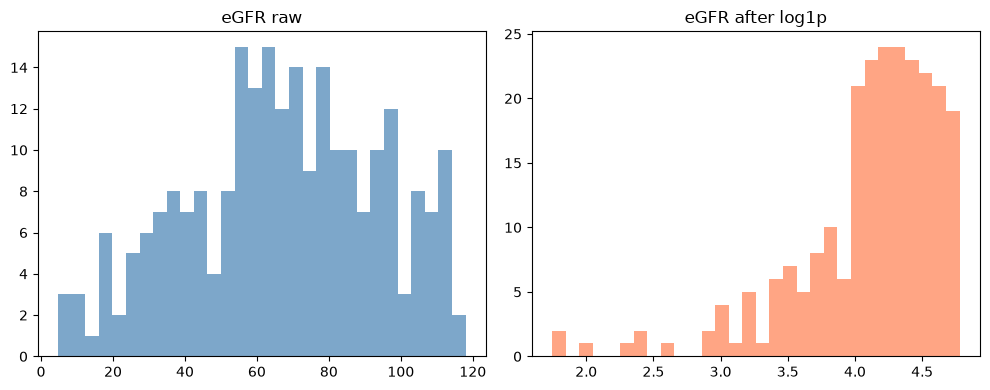

In [32]:
for name, X in [("baseline", X_train), ("fe", Xtr_fe)]:
    print(f"{name:9s}", X.shape, "NaN:", X.isnull().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw_tr_fe["egfr"], bins=30, color="steelblue", alpha=0.7)
axes[0].set_title("eGFR raw")
axes[1].hist(Xtr_fe["log__egfr"], bins=30, color="coral", alpha=0.7)
axes[1].set_title("eGFR after log1p")
plt.tight_layout(); plt.show()

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "AUC": make_scorer(roc_auc_score, response_method="predict_proba"),
    "F1": make_scorer(f1_score),
}

def cv_results(X, y, model):
    return {m: cross_val_score(model, X, y, cv=cv, scoring=s).mean().round(4)
            for m, s in scorers.items()}

In [ ]:
models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
}

rows = []
for mname, model in models.items():
    for fname, X in [("baseline", X_train), ("fe", Xtr_fe)]:
        r = cv_results(X, y_train, model)
        r |= {"model": mname, "features": fname}
        rows.append(r)

res = pd.DataFrame(rows)
print(res.sort_values("AUC", ascending=False))

      AUC      F1         model  features
3  0.9081  0.7221  RandomForest        fe
2  0.9068  0.7443  RandomForest  baseline
1  0.9045  0.7573        LogReg        fe
0  0.8984  0.7663        LogReg  baseline


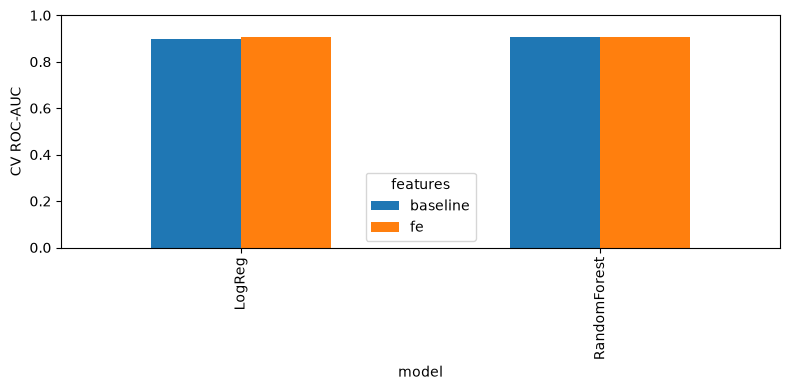

In [37]:
res.pivot(index="model", columns="features", values="AUC").plot(kind="bar", figsize=(8, 4))
plt.ylabel("CV ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout(); plt.show()

From the result above, there is no significant improvement after feature engineering (egfr and ef_group). The AUC difference between the baseline and fe is to small to believe. <br>
<0.01 difference with 299 rows dataset almost certainly noise. F1-score consistently declining in both model. However, the F1-score is prioritized because the data is imbalanced. <br>
Feature engineering adding complexity without any profit. New feature (eGFR replaces creatinine, plus ef_group) adding interpretation complexity.

After this testing for feature engineering process, no need to export new dataset after fe because there is no significant improvement. So for modelling, use the existing <br>
train and test set without exporting after fe. 